<a href="https://colab.research.google.com/github/tanvibeer12/Pattern-Recognition/blob/main/CM23020_pr_04ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print("Files Extracted Successfully")

Files Extracted Successfully


In [ ]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy : 65.85 %


In [ ]:
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_imputed, y_train)

knn_pred = knn.predict(X_test_imputed)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", round(knn_accuracy*100,2),"%")

KNN Accuracy : 61.79 %


In [ ]:

print("Decision Tree Report\n")
print(classification_report(y_test, dt_pred))

print("\nKNN Report\n")
print(classification_report(y_test, knn_pred))

Decision Tree Report

              precision    recall  f1-score   support

           0       0.51      0.49      0.50        43
           1       0.73      0.75      0.74        80

    accuracy                           0.66       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.65      0.66      0.66       123


KNN Report

              precision    recall  f1-score   support

           0       0.36      0.12      0.18        43
           1       0.65      0.89      0.75        80

    accuracy                           0.62       123
   macro avg       0.50      0.50      0.46       123
weighted avg       0.55      0.62      0.55       123



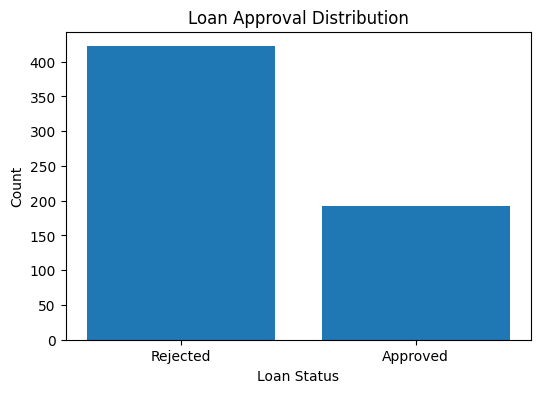

In [ ]:
# Loan Approval Count

loan = df["Loan_Status"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["Rejected","Approved"], loan.values)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

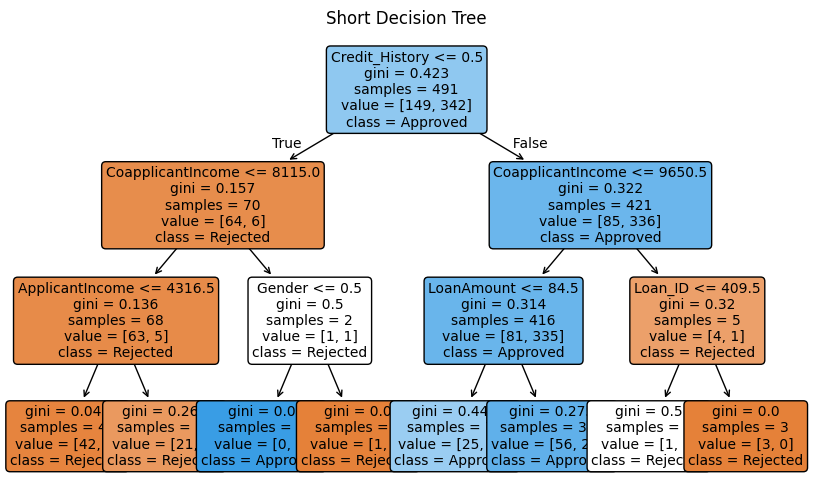

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Short Decision Tree")
plt.show()